# Vol 25 — Carbon, Weather & Renewable PPAs

**問い:** 非完備市場のpremium、location basis、PPA shape/volume riskをどう分けるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

carbon GBM/Heston/SV+jump、temperature seasonality/OU/fOU、station basis、fixed/pay-as-produced/floor-collar PPAを分ける。fair value・CFaR/CVaR・hedge residualを別々に報告し、storage optionはresearch trackへ隔離する。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'scenarios.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 25
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=25 digest=46969f01a8f61e14 arrays=47


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

carbon_atm_black76_price: 9.750668398221954
carbon_atm_heston_price: 9.293620958236868
carbon_atm_jump_price: 9.77883384942297
carbon_atm_standard_error: 0.17495521242041653
carbon_model_ladder_complete: True
hedge_residual: 40.42651541814297
market_completeness: incomplete
ppa_cash_flow_at_risk95: 65.69238346389739
ppa_cvar95: 82.3691062150823
ppa_hedge_residual: 40.42651541814297
premium_principle: standard_deviation
price_generation_correlation: -0.5927276785284812
weather_basis_rmse_100km: 2.4258099230251826
weather_fou_lag1_autocorrelation: 0.9661916217361509
weather_ou_lag1_autocorrelation: 0.8306188484659933
weather_premium_principle: standard_deviation


## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS market_completeness incomplete == incomplete
PASS premium_principles 3 three explicit non-traded-index principles
PASS carbon_premium_sensitivity 1.1303935436982258 > 0
PASS carbon_model_ladder 4 Black-76 and three MC models with aligned uncertainty
PASS weather_long_memory 0.9661916217361509 fractional OU lag-1 correlation exceeds OU with finite degree-day moments
PASS weather_basis_risk 5.566902660585961 increases from zero-distance baseline
PASS basis_hedge_diagnostics 0.9999414442205588 finite hedge ratios and variance reduction in [0, 1]
PASS ppa_risk_decomposition 3 finite CVaR/residual and hedge sensitivity
PASS ppa_cashflow_risk 65.69238346389739 finite aligned CFaR diagnostics and CVaR >= CFaR > 0


## carbon GBM vs SV+jump smile

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

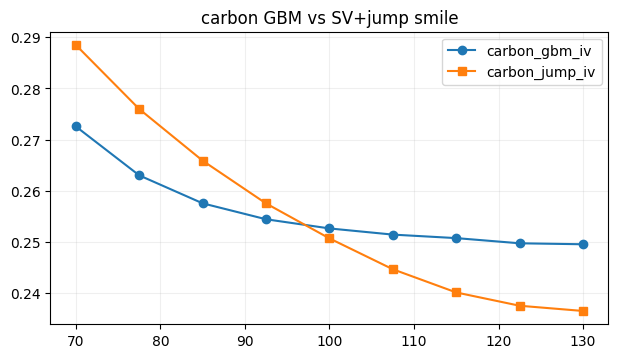

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("carbon GBM vs SV+jump smile")
ax.plot(data["strike"], data["carbon_gbm_iv"], marker="o", label="carbon_gbm_iv")
ax.plot(data["strike"], data["carbon_jump_iv"], marker="s", label="carbon_jump_iv")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## temperature OU vs fOU

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

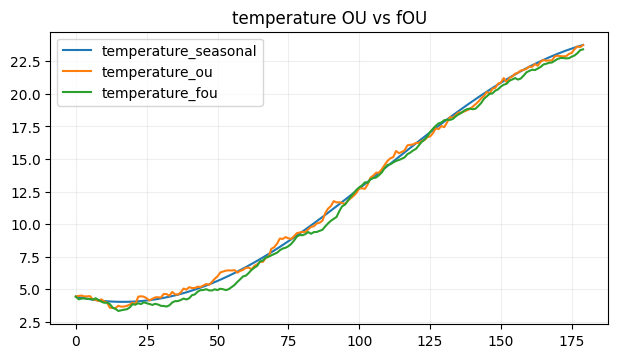

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("temperature OU vs fOU")
ax.plot(data["day"], data["temperature_seasonal"], label="temperature_seasonal")
ax.plot(data["day"], data["temperature_ou"], label="temperature_ou")
ax.plot(data["day"], data["temperature_fou"], label="temperature_fou")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## station/location basis risk

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

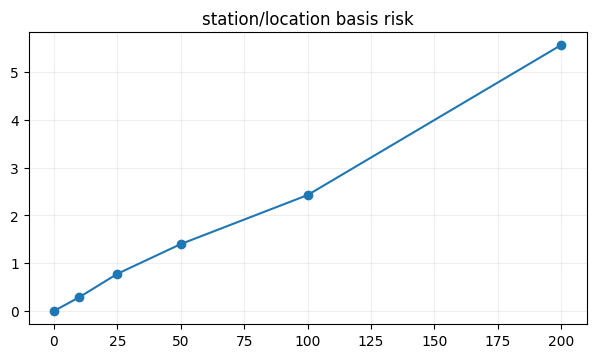

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("station/location basis risk")
ax.plot(data["station_distance_km"], data["basis_rmse"], marker="o")
ax.grid(alpha=.2)
plt.show()

## PPA CFaR/CVaR and hedge residual

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

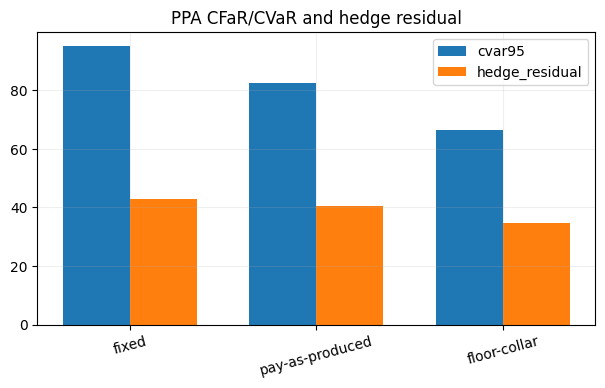

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("PPA CFaR/CVaR and hedge residual")
x = np.arange(len(data["risk_names"]))
ax.bar(x - .18, data["cvar95"], width=.36, label="cvar95")
ax.bar(x + .18, data["hedge_residual"], width=.36, label="hedge_residual")
ax.set_xticks(x, data["risk_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [8]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Benth & Benth (2013), Modeling and Pricing in Financial Markets for Weather Derivatives; energy PPA literature.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。